# Generate tiled background images to custom colour-spec

I have a reference image in mind: https://pin.it/7AS48JaPy

I want to create a possible vertically infinite checker-board pattern with a fixed width, and at some small percentage of of the checks, I want to generate a quadrilateral which will take on a shape in a specified range, and a solid colour from a selection, at random.

Colour palette reference: https://coolors.co/palette/f0ead2-dde5b6-adc178-a98467-6c584c

In [ ]:
# Define imports
from PIL import Image, ImageDraw
from IPython.display import display, clear_output
from time import sleep
import numpy as np
RAND_STATE = 335
rand = np.random.RandomState(RAND_STATE)

# Define square (each square on the checkerboard) and board dimensions
square_size = 30
cols = 40
rows = 60
padding = 40

# Create an image with pillow (base canvas is larger than desired for checkerboard)
background_color = "#" #"#FFF4EA"
width = cols * square_size + 2 * padding
height = rows * square_size + 2 * padding
plain_img = Image.new("RGB", (width, height), background_color)
gradient_img = Image.new("RGB", (width, height), background_color)
draw = ImageDraw.Draw(plain_img)

In [12]:
(24*80), (14*80) , 16/9

(1920, 1120, 1.7777777777777777)

Setup the logic to sample some percentage of the squares, randomly define the dimensions of a new quadrilateral, and impose it on the existing grid.

In [24]:
# Sample a small number of indices
num_squares = cols * rows
square_list = np.zeros_like(range(num_squares))

# since I have the total number, I want a coin to be flipped yes ca. 5-8% of the times.
threshold = 0.1
for i, s in enumerate(square_list):
    random_draw = rand.uniform(0, 1)
    noisy_threshold = threshold + rand.uniform(-0.02, 0.02)  # Add some noise to the threshold
    if random_draw < noisy_threshold:
        square_list[i] = 1  # Mark this square as "flipped"
        print(f"Square {i} flipped (random_draw: {random_draw:.4f}, threshold: {noisy_threshold:.4f})")

print(f"Total flipped squares: {np.sum(square_list)} out of {num_squares}")

Square 31 flipped (random_draw: 0.0991, threshold: 0.1064)
Square 42 flipped (random_draw: 0.0125, threshold: 0.0991)
Square 59 flipped (random_draw: 0.0474, threshold: 0.0818)
Square 62 flipped (random_draw: 0.0065, threshold: 0.1016)
Square 64 flipped (random_draw: 0.0512, threshold: 0.1032)
Square 67 flipped (random_draw: 0.0691, threshold: 0.0965)
Square 95 flipped (random_draw: 0.0914, threshold: 0.1152)
Square 99 flipped (random_draw: 0.0253, threshold: 0.1007)
Square 111 flipped (random_draw: 0.0277, threshold: 0.1115)
Square 114 flipped (random_draw: 0.0382, threshold: 0.0889)
Square 115 flipped (random_draw: 0.0019, threshold: 0.0837)
Square 127 flipped (random_draw: 0.0628, threshold: 0.1066)
Square 148 flipped (random_draw: 0.0084, threshold: 0.1166)
Square 150 flipped (random_draw: 0.0699, threshold: 0.0835)
Square 151 flipped (random_draw: 0.0836, threshold: 0.1050)
Square 160 flipped (random_draw: 0.0522, threshold: 0.0828)
Square 163 flipped (random_draw: 0.0515, thresho

In [35]:
def clear_display():
    # display drawing progression
    clear_output(wait=True)
    display(plain_img)
    sleep(0.05)
    
# Build the checkers
for row in range(rows):
    for col in range(cols):
        if (row + col) % 2 == 0:                # i.e. each even-numbered square
            x0 = col * square_size + padding
            y0 = row * square_size + padding    # starting pixels for x and y; (0 * 50) for col/row = 0
            x1 = x0 + square_size
            y1 = y0 + square_size               # ending pixels for x and y
            draw.rectangle([x0, y0, x1, y1], fill="#4c956c")

        # if square_list[row * cols + col] == 1:  # Check if this square was marked as flipped
        #     draw.rectangle([col * square_size + padding, row * square_size + padding, (col + 1) * square_size + padding, (row + 1) * square_size + padding], fill="pink")

        # clear_display()



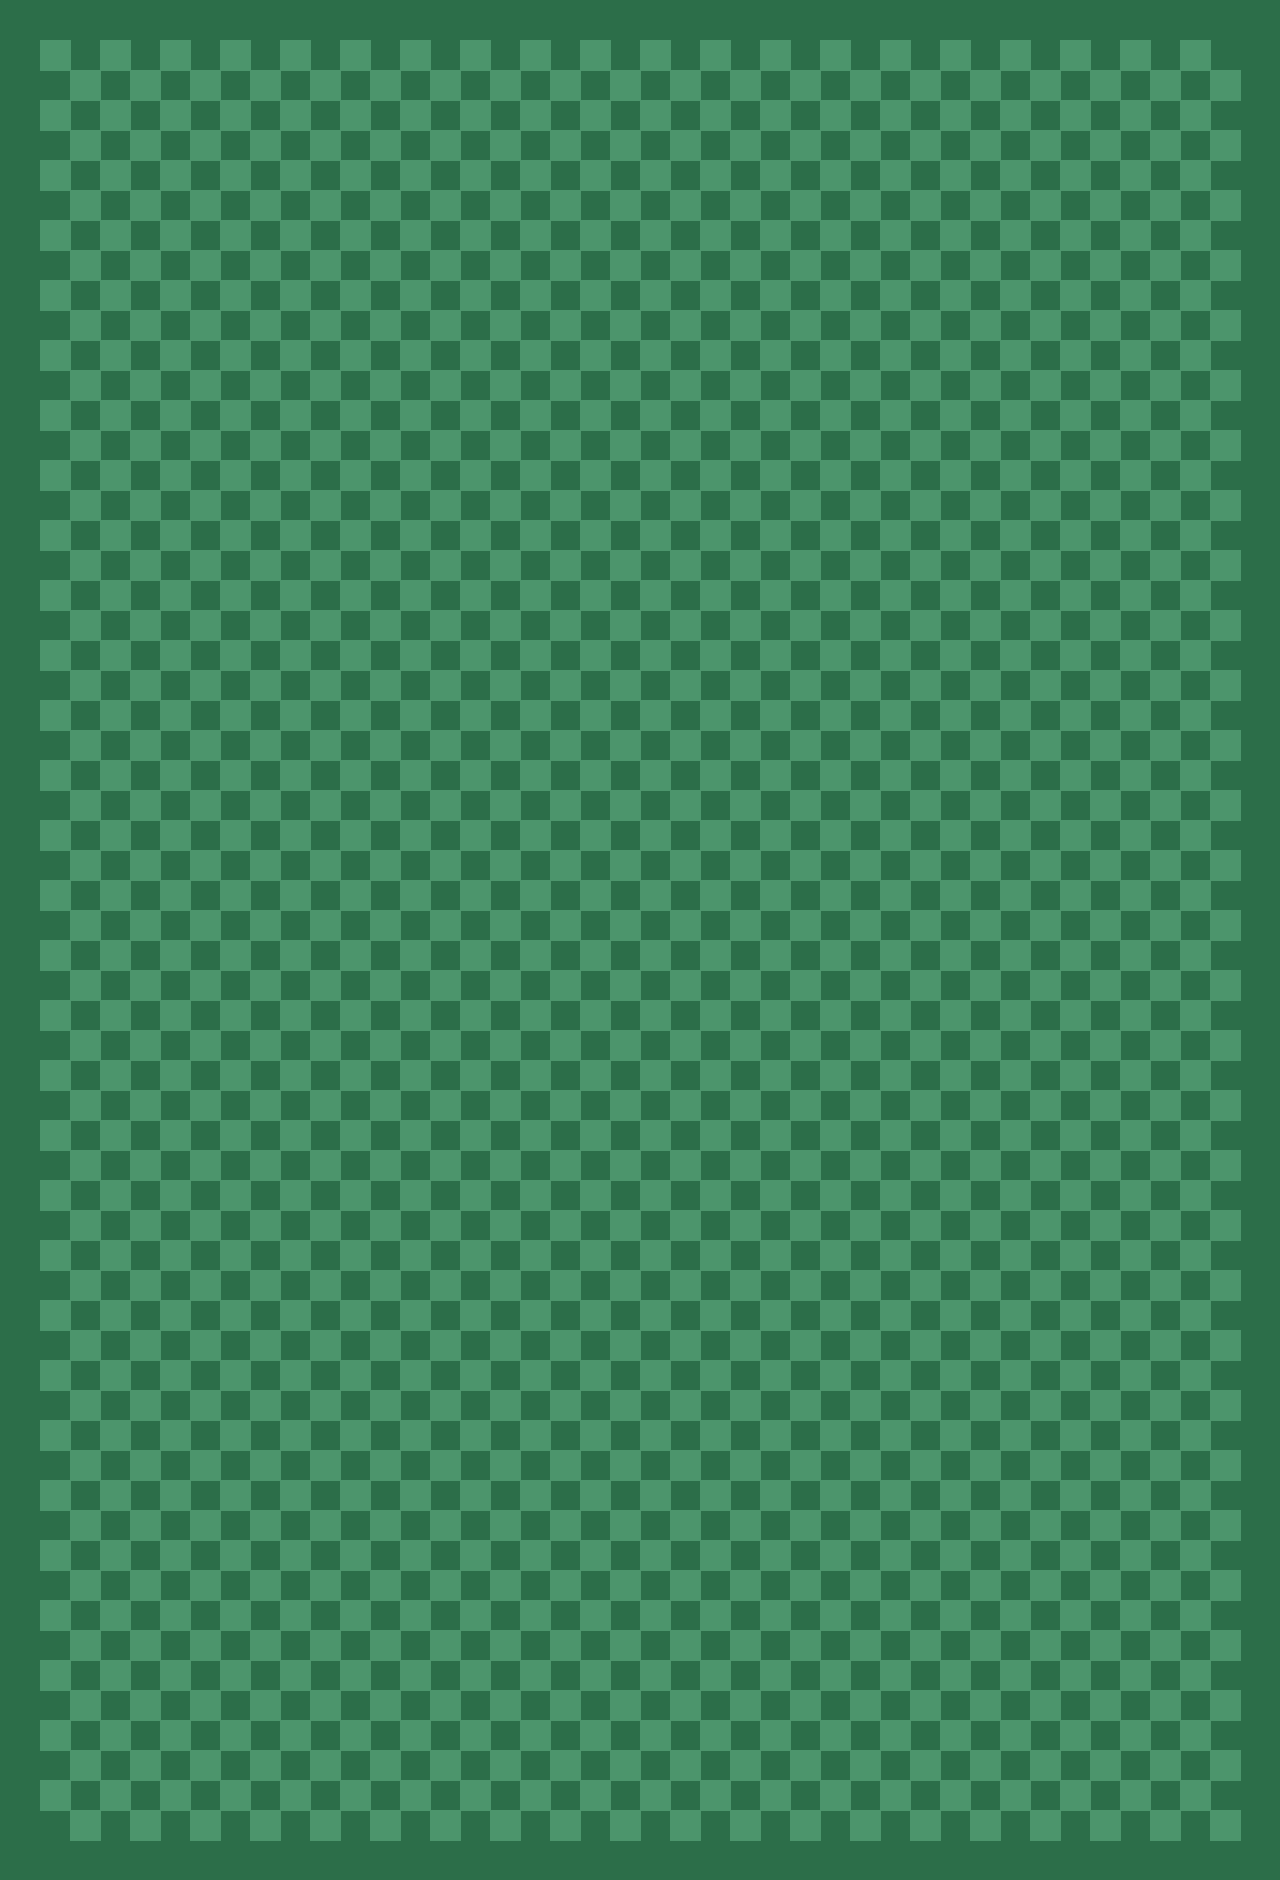

In [36]:
display(plain_img)

In [37]:
from pathlib import Path
root = Path.cwd().parent
images = root / "images"
images.mkdir(exist_ok=True)

plain_img.save(images / "index_checkerboard_green.png")

In [ ]:
# Build the checkers
start_r, start_g, start_b = 76, 149, 108
for row in range(rows):
    for col in range(cols):
        if (row + col) % 2 == 0:                # i.e. each even-numbered square
            x0 = col * square_size + padding
            y0 = row * square_size + padding    # starting pixels for x and y; (0 * 50) for col/row = 0
            x1 = x0 + square_size
            y1 = y0 + square_size               # ending pixels for x and y
            draw.rectangle([x0, y0, x1, y1], fill="#4c956c")

